In [2]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
  return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

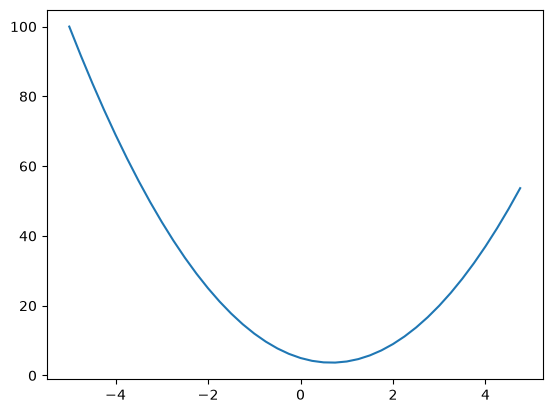

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 0.000001
x = 2/3
(f(x + h) - f(x))/h

2.999378523327323e-06

In [6]:
# les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)


d1 4.0
d2 4.0001
slope 0.9999999999976694


In [1]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
  
  def __rmul__(self, other): # other * self # 2 * a but 2 is not a Value Object, python will go a * 2 with rmul
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self 
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    
    def _backward():
      self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
    out._backward = _backward
    
    return out
  
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()



In [3]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


In [318]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

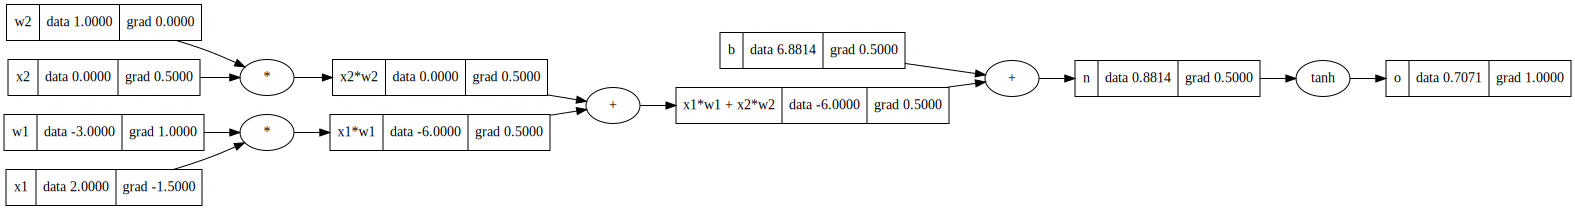

In [319]:
draw_dot(o)

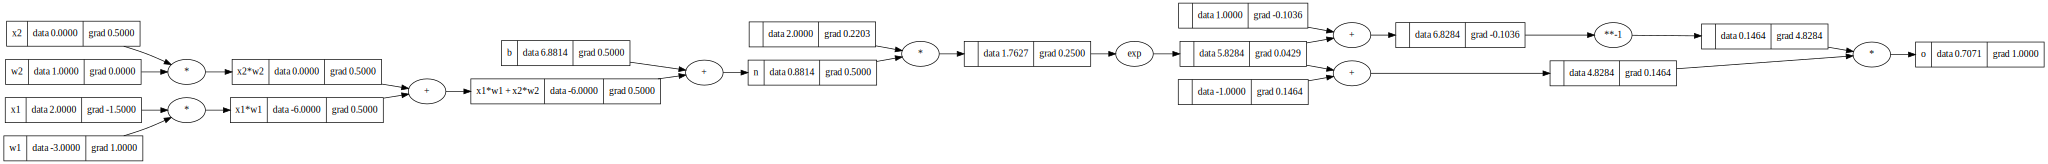

In [ ]:
# Break down the tanh(x) into operations (add exp sub div)
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

In [1]:
import torch # pytorch exactly do the same thing

In [ ]:
# take a look to compare to above
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [3]:
# Typical CV batch: (B, C, H, W)
vision_tensor = torch.randn(
    size=(16, 3, 224, 224),       # 16 images, 3 channels (RGB), 224x224
    dtype=torch.float32,          # 32-bit float
    device=torch.device('cuda'),   # 'cpu' or 'cuda'
    requires_grad=True            # Enable gradient tracking
)

# Convert to Channels Last memory format for optimized convolutions
vision_tensor = vision_tensor.to(memory_format=torch.channels_last)

print("Shape:", vision_tensor.shape)
print("Requires Grad:", vision_tensor.requires_grad)

Shape: torch.Size([16, 3, 224, 224])
Requires Grad: True


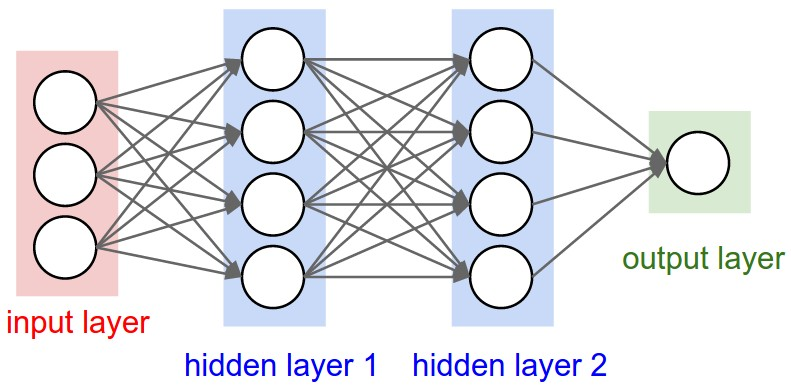

In [ ]:
# we built neuron before but here we build it subscribe to pytorch api
class Neuron:
  
  def __init__(self, nin): # numbers of inputs to the neuron
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # take neuron input x and compute w * x + b
    # zip(w,x)=[(w1,x1),(w2,x2)]
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer: # a list of neurons
  
  def __init__(self, nin, nout): # single nout scalar for one layer
    self.neurons = [Neuron(nin) for _ in range(nout)] # literally a list of neurons
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons] # independently evaluate
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):

    # params=[]
    # for neuron in self.neurons:
    #   ps = neuron.parameters()
    #   params.extend(ps)
    # return params
    
    return [p for neuron in self.neurons for p in neuron.parameters()]
  
    # for neuron in self.neurons:
    #   for p in neuron.parameters():
    #       collect p

class MLP:
  
  def __init__(self, nin, nouts): # a list of nout = nouts, sizes for every layers
    sz = [nin] + nouts # nin=3, nouts=[4,4,1] -> [3,4,4,1] 
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] # build layers: [Layer(3,4), Layer(4,4), Layer(4,1)]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x) # feed output of current layer as input to next layer
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [8]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.4914141285583769)

In [ ]:
draw_dot(n(x))

In [14]:
n.parameters()

[Value(data=-0.36786015806867045),
 Value(data=-0.21417879427174724),
 Value(data=0.608058752181807),
 Value(data=0.9469940331832625),
 Value(data=-0.006915471051767819),
 Value(data=0.24615017885241786),
 Value(data=-0.2713994119925356),
 Value(data=-0.4582938863795414),
 Value(data=-0.6944846888467551),
 Value(data=-0.7979356673219653),
 Value(data=0.1089334856833466),
 Value(data=-0.8932076077152327),
 Value(data=-0.08726516053749855),
 Value(data=0.9086124573336609),
 Value(data=0.9310043580676648),
 Value(data=0.4116218644952485),
 Value(data=-0.03555052789442059),
 Value(data=-0.8503867048159817),
 Value(data=0.36623633837097924),
 Value(data=-0.2873159951755351),
 Value(data=0.5194819415436271),
 Value(data=-0.2832278653140545),
 Value(data=0.30141792266638934),
 Value(data=-0.5229132225481625),
 Value(data=-0.38382132194485896),
 Value(data=-0.1956739066180624),
 Value(data=0.9487251505636192),
 Value(data=0.999634402815661),
 Value(data=0.6242599370895814),
 Value(data=-0.4005

In [15]:
len(n.parameters())

41

In [6]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
] # 4 datasets
ys = [1.0, -1.0, -1.0, 1.0] # desired targets for each datasets

In [9]:
ypred = [n(x) for x in xs]
ypred

[Value(data=0.4914141285583769),
 Value(data=0.27110567689214227),
 Value(data=0.28699127064761953),
 Value(data=0.28397979272582696)]

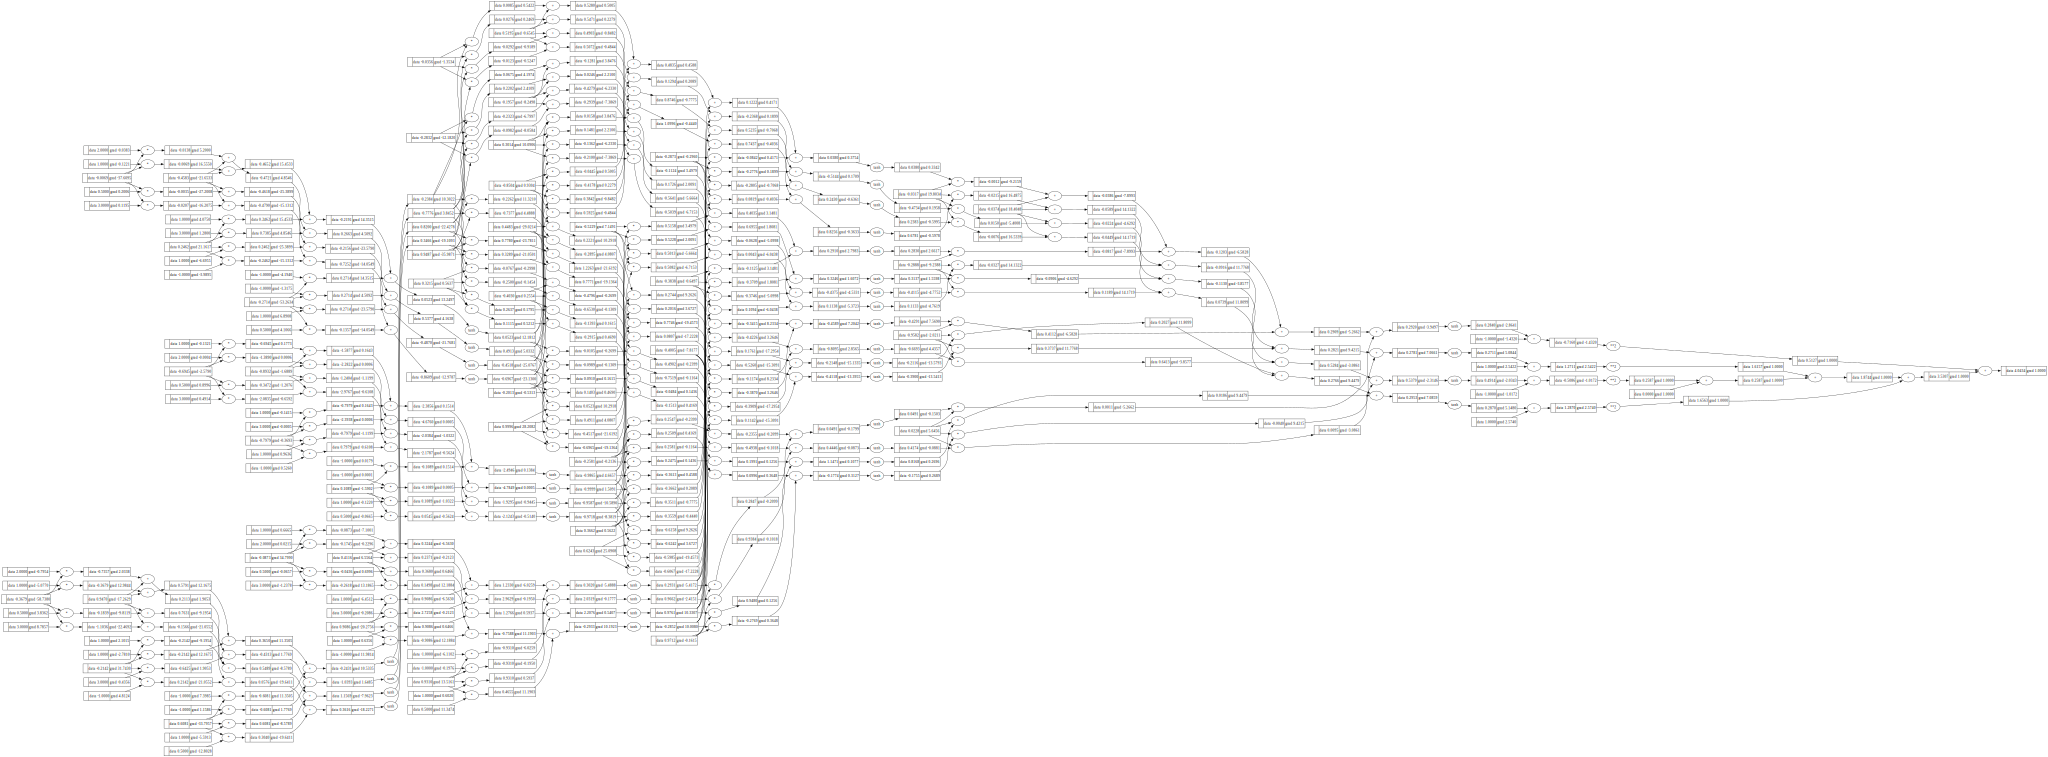

In [11]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss
loss.backward()
n.layers[0].neurons[0].w[0].grad
draw_dot(loss)

In [16]:

for k in range(30):
  
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred)) # single scalar
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad
  
  print(k, loss.data)
  

0 4.04340069840559
1 2.3835611690994307
2 1.0309843270969659
3 0.24770263128664893
4 0.1695070875693689
5 0.13337446857662605
6 0.11098223926181588
7 0.095350539404267
8 0.08368994540971264
9 0.07460818130371494
10 0.06731376996549956
11 0.06131658646348468
12 0.056294106624798626
13 0.052024189714491825
14 0.04834827405992527
15 0.04514986837484039
16 0.042341320923497176
17 0.039855336170231855
18 0.037639345535333144
19 0.0356516623566234
20 0.033858789627392416
21 0.032233493899732964
22 0.030753401051911385
23 0.029399955254861027
24 0.028157635580965772
25 0.027013358516746085
26 0.025956016687306245
27 0.024976118776791276
28 0.02406550558532656
29 0.023217124033374448


In [17]:
ypred

[Value(data=0.9306992258563744),
 Value(data=-0.932405461133101),
 Value(data=-0.9168502206346245),
 Value(data=0.9167436534351326)]